# Project Deep Learning: Klasifikasi Mata Uang Kertas Menggunakan ResNet18

Notebook ini merupakan tugas proyek mata kuliah Deep Learning yang berfokus pada **fine-tuning model ResNet18 untuk klasifikasi citra**. Alur notebook dibuat rapi, runtut dan mudah dipahami. Beberapa poin yang dibahas pada project ini adalah: rumusan masalah dan tujuan; pemilihan dan pemahaman data; pra-pemrosesan dan eksplorasi data; ketepatan metode; implementasi program; proses pelatihan/eksperimen; evaluasi hasil dan metrik; interpretasi hasil; kualitas notebook/presentasi; serta reproduksibilitas dan etika akademik.

## 1. Rumusan masalah dan tujuan proyek

### Latar belakang
Kemampuan untuk mengidentifikasi dan mengklasifikasikan denominasi uang kertas secara andal memiliki implikasi praktis yang besar dalam berbagai domain, seperti mesin ATM, terminal point-of-sale, mesin penjual otomatis, serta perangkat bantu bagi penyandang tunanetra untuk membedakan nominal uang. Dalam konteks Indonesia, Rupiah diterbitkan dalam tujuh denominasi utama dengan kemiripan warna dan ukuran visual tertentu, sehingga pembedaan manual dapat menjadi sulit, terutama pada kondisi yang terburu-buru atau pencahayaan yang kurang baik. Oleh karena itu, sistem pengenalan uang kertas otomatis yang mampu bekerja pada variasi pencahayaan, sudut pengambilan gambar, dan tingkat keausan fisik memiliki nilai praktis dan sosial yang tinggi.

### Rumusan masalah
Bagaimana membangun model deep learning berbasis **ResNet18** yang mampu mengklasifikasikan nominal mata uang kertas secara akurat dari citra digital?

### Tujuan proyek
- Membangun pipeline klasifikasi citra end-to-end menggunakan PyTorch.
- Melatih model ResNet18 untuk mengenali kelas nominal mata uang.
- Mengevaluasi performa model dengan metrik yang tepat.
- Menyusun notebook yang dapat dipakai sebagai bahan implementasi dan dokumentasi project.

### Indikator keberhasilan
- Pipeline dapat dijalankan tanpa error.
- Dataset dipisah menjadi train, validation, dan test.
- Model terbaik dipilih berdasarkan validation loss.
- Evaluasi final dilakukan pada test set terpisah.
- Hasil tidak hanya ditampilkan, tetapi juga diinterpretasikan.

## 2. Pemahaman data dan sumber data

Dataset yang digunakan dalam penelitian ini diperoleh dari Kaggle pada tautan https://www.kaggle.com/code/nasdevs/indonesian-rupiah-currency-classification dan terdiri atas 2.395 citra RGB uang kertas Rupiah Indonesia yang mencakup tujuh kelas denominasi, yaitu Rp1.000, Rp2.000, Rp5.000, Rp10.000, Rp20.000, Rp50.000, dan Rp100.000. Dataset ini memuat variasi alami yang umum dijumpai pada kondisi nyata, seperti perbedaan kondisi fisik uang (baru dan lusuh), intensitas serta arah pencahayaan, distorsi perspektif ringan, dan latar belakang yang beragam. Variasi ini membuat proses klasifikasi menjadi lebih menantang, tetapi sekaligus meningkatkan relevansi praktis penelitian. Dataset tersusun dalam bentuk folder per kelas nominal, sehingga sesuai untuk diproses dengan `ImageFolder` pada PyTorch.

### Alasan data ini relevan
- Masalah yang diselesaikan adalah klasifikasi citra nominal uang, sehingga data citra per nominal adalah sumber yang tepat.
- Struktur folder per kelas mempermudah proses pelabelan otomatis.
- Data visual cocok diproses dengan arsitektur CNN modern seperti ResNet18.

In [1]:
# BLOK 1 - IMPORT LIBRARY
# Bagian ini mengimpor seluruh library utama untuk pengolahan data, visualisasi, deep learning, dan evaluasi.

import os
import shutil
import random
import time
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import matplotlib.pyplot as plt
import seaborn as sns

# Style visualisasi dibuat konsisten agar grafik lebih mudah dibaca saat analisis dan presentasi.
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

## 3. Konfigurasi path, output, dan reproducibility

Penetapan path, folder output, dan random seed dilakukan di awal agar eksperimen mudah diulang dan mendukung aspek reproduksibilitas.

In [2]:
# BLOK 2 - KONFIGURASI PATH DAN REPRODUCIBILITY

# Folder dataset sumber, diasumsikan berisi subfolder per kelas nominal.
SOURCE_DIR = './datasetBN'

# Folder hasil split train/validation/test.
SPLIT_DIR = './datasetBN_split_resnet18'

# Folder output untuk menyimpan model, CSV hasil, dan artefak eksperimen.
OUTPUT_DIR = './hasil_resnet18_project'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Seed global untuk memastikan pembagian data dan proses acak dapat direproduksi.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print('SOURCE_DIR :', SOURCE_DIR)
print('SPLIT_DIR  :', SPLIT_DIR)
print('OUTPUT_DIR :', OUTPUT_DIR)
print('RANDOM_SEED:', RANDOM_SEED)

SOURCE_DIR : ./datasetBN
SPLIT_DIR  : ./datasetBN_split_resnet18
OUTPUT_DIR : ./hasil_resnet18_project
RANDOM_SEED: 42


## 4. Audit struktur dataset

Sebelum training, kita perlu memastikan setiap folder kelas benar-benar berisi gambar. Audit ini menunjukkan bahwa pemahaman data dan eksplorasi awal dilakukan secara sistematis.

In [3]:
# BLOK 3 - AUDIT STRUKTUR DATASET

# Fungsi untuk membaca jumlah file pada setiap folder kelas.
def audit_dataset_structure(source_dir):
    summary = []
    if not os.path.exists(source_dir):
        raise FileNotFoundError(f'Dataset source tidak ditemukan: {source_dir}')

    for class_name in sorted(os.listdir(source_dir)):
        class_dir = os.path.join(source_dir, class_name)
        if os.path.isdir(class_dir):
            files = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
            summary.append({'class_name': class_name, 'num_images': len(files)})

    return pd.DataFrame(summary)

# Menjalankan audit dan menampilkan ringkasan jumlah gambar per kelas.
df_source_summary = audit_dataset_structure(SOURCE_DIR)
display(df_source_summary)
print('Total kelas :', len(df_source_summary))
print('Total gambar:', int(df_source_summary['num_images'].sum()))

,class_name,num_images
0,1000,334
1,10000,344
2,100000,344
3,2000,344
4,20000,344
5,5000,341
6,50000,344


Total kelas : 7
Total gambar: 2395


## 5. Split dataset train, validation, dan test

Dataset dibagi ke tiga subset agar eksperimen valid: train untuk belajar, validation untuk seleksi model, dan test untuk evaluasi akhir. Hal ini bertujuan agar performa yang dilaporkan tidak bias oleh data yang pernah dilihat saat training dan hasil eksperimen lebih valid, adil, serta dapat dipercaya sebagai gambaran kemampuan model di data baru.

In [4]:
# BLOK 4 - SPLIT DATASET TRAIN / VALIDATION / TEST

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Menghapus folder split lama agar eksperimen dimulai dari kondisi yang bersih.
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

# Membuat struktur folder train, val, dan test untuk setiap kelas.
for split_name in ['train', 'val', 'test']:
    for class_name in sorted(os.listdir(SOURCE_DIR)):
        class_dir = os.path.join(SOURCE_DIR, class_name)
        if os.path.isdir(class_dir):
            os.makedirs(os.path.join(SPLIT_DIR, split_name, class_name), exist_ok=True)

# Melakukan split per kelas agar distribusi relatif terjaga di tiap subset.
for class_name in sorted(os.listdir(SOURCE_DIR)):
    class_dir = os.path.join(SOURCE_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue

    image_files = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
    random.shuffle(image_files)

    total_images = len(image_files)
    train_end = int(total_images * TRAIN_RATIO)
    val_end = train_end + int(total_images * VAL_RATIO)

    train_files = image_files[:train_end]
    val_files = image_files[train_end:val_end]
    test_files = image_files[val_end:]

    for file_list, split_name in [
        (train_files, 'train'),
        (val_files, 'val'),
        (test_files, 'test')
    ]:
        for file_name in tqdm(file_list, desc=f'{class_name}-{split_name}', leave=False):
            src_path = os.path.join(class_dir, file_name)
            dst_path = os.path.join(SPLIT_DIR, split_name, class_name, file_name)
            shutil.copy(src_path, dst_path)

print('Proses split dataset selesai.')

Proses split dataset selesai.


## 6. Eksplorasi distribusi data setelah split

Setelah split, distribusi jumlah gambar pada tiap kelas perlu diperiksa, sehingga memastikan pra-pemrosesan dan eksplorasi data dilakukan secara sistematis dan benar.

In [5]:
# BLOK 5 - RINGKASAN DISTRIBUSI DATA SETELAH SPLIT

# Fungsi untuk menghitung jumlah sampel per kelas di setiap split.
def summarize_split(split_dir):
    rows = []
    for split_name in ['train', 'val', 'test']:
        split_path = os.path.join(split_dir, split_name)
        for class_name in sorted(os.listdir(split_path)):
            class_path = os.path.join(split_path, class_name)
            if os.path.isdir(class_path):
                num_files = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
                rows.append({'split': split_name, 'class_name': class_name, 'num_images': num_files})
    return pd.DataFrame(rows)

# Membuat tabel ringkasan distribusi.
df_split_summary = summarize_split(SPLIT_DIR)
display(df_split_summary)

# Pivot table memudahkan pembacaan distribusi antar split.
df_pivot = df_split_summary.pivot(index='class_name', columns='split', values='num_images').fillna(0).astype(int)
display(df_pivot)

# Menyimpan ringkasan agar bisa dipakai dalam laporan atau presentasi.
df_split_summary.to_csv(os.path.join(OUTPUT_DIR, 'split_summary_long.csv'), index=False)
df_pivot.to_csv(os.path.join(OUTPUT_DIR, 'split_summary_pivot.csv'))

,split,class_name,num_images
0,train,1000,233
1,train,10000,240
2,train,100000,240
3,train,2000,240
4,train,20000,240
5,train,5000,238
6,train,50000,240
7,val,1000,50
8,val,10000,51
9,val,100000,51


split,test,train,val
class_name,,,
1000,51,233,50
10000,53,240,51
100000,53,240,51
2000,53,240,51
20000,53,240,51
5000,52,238,51
50000,53,240,51


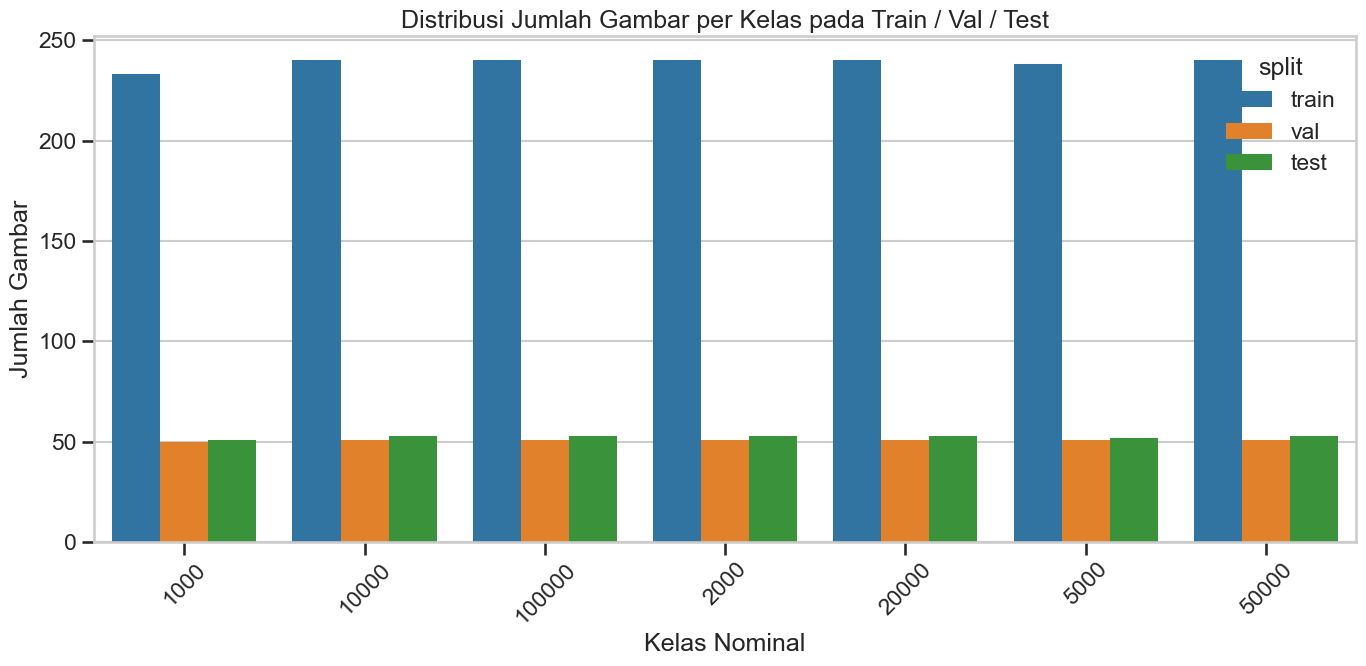

In [6]:
# BLOK 6 - VISUALISASI DISTRIBUSI DATA

# Grafik batang dipakai untuk melihat apakah distribusi data cukup seimbang antar kelas dan antar split.
plt.figure(figsize=(14, 7))
sns.barplot(data=df_split_summary, x='class_name', y='num_images', hue='split')
plt.title('Distribusi Jumlah Gambar per Kelas pada Train / Val / Test')
plt.xlabel('Kelas Nominal')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Konfigurasi eksperimen dan hyperparameter

Sebelum model ResNet18 dilatih, kita perlu menetapkan terlebih dahulu konfigurasi eksperimen seperti ukuran input, batch size, jumlah epoch, learning rate, dan aturan early stopping. Hal ini bertujuan agar rancangan eksperimen mudah dibaca, mudah direproduksi, dan memudahkan dalam menelusuri pengaruh tiap pengaturan terhadap performa model.

In [7]:
# BLOK 7 - HYPERPARAMETER EKSPERIMEN

# Ukuran input 224x224 dipilih karena sesuai dengan standar input ResNet18 pretrained ImageNet.
IMG_SIZE = 224

# Batch size 32 dipilih karena umum dipakai dan masih ramah untuk GPU kelas menengah.
BATCH_SIZE = 32

# Epoch 20 dipakai sebagai batas atas fine-tuning awal yang seimbang antara waktu dan peluang konvergensi.
EPOCHS = 20

# Learning rate kecil dipakai agar bobot pretrained tidak berubah terlalu agresif saat fine-tuning.
LEARNING_RATE = 1e-4

# Early stopping menjaga training agar tidak terlalu lama ketika validation loss stagnan.
PATIENCE = 5

# Jumlah worker DataLoader dapat disesuaikan dengan environment komputasi.
NUM_WORKERS = 2

print('Konfigurasi eksperimen')
print('IMG_SIZE      :', IMG_SIZE)
print('BATCH_SIZE    :', BATCH_SIZE)
print('EPOCHS        :', EPOCHS)
print('LEARNING_RATE :', LEARNING_RATE)
print('PATIENCE      :', PATIENCE)
print('NUM_WORKERS   :', NUM_WORKERS)

Konfigurasi eksperimen
IMG_SIZE      : 224
BATCH_SIZE    : 32
EPOCHS        : 20
LEARNING_RATE : 0.0001
PATIENCE      : 5
NUM_WORKERS   : 2


## 8. Menentukan device komputasi

Pemilihan device membuat notebook fleksibel: dapat berjalan di GPU jika tersedia, namun tetap kompatibel dengan CPU.

In [8]:
# BLOK 8 - MENENTUKAN DEVICE KOMPUTASI

if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Device yang digunakan:', device)

Device yang digunakan: cuda


## 9. Data augmentation dan preprocessing

Pada bagian ini dijelaskan tahapan data augmentation dan preprocessing yang menjadi bagian penting dari metodologi eksperimen. Langkah-langkah ini bertujuan untuk menyiapkan citra dalam format yang sesuai dengan ResNet18 sekaligus meningkatkan kemampuan generalisasi model melalui augmentasi ringan pada data training, sementara data validation dan test diproses secara konsisten tanpa augmentasi acak agar evaluasi tetap adil.

In [9]:
# BLOK 9 - DATA AUGMENTATION DAN PREPROCESSING

# Transformasi data training menggunakan augmentasi ringan agar model lebih robust terhadap variasi kecil.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Validation dan test tidak memakai augmentasi acak agar evaluasi konsisten dan adil.
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## 10. Load dataset dan DataLoader

Bagian ini menyiapkan objek dataset dan DataLoader untuk proses training, validation, dan testing. Ini juga bisa dijadikan sebagai bahan dokumentasi implementasi agar lebih lengkap

In [10]:
# BLOK 10 - LOAD DATASET DAN DATALOADER

train_dataset = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'train'), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'val'), transform=val_test_transform)
test_dataset = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'test'), transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print('Kelas yang terdeteksi :', CLASS_NAMES)
print('Jumlah kelas          :', NUM_CLASSES)
print('Sampel training       :', len(train_dataset))
print('Sampel validation     :', len(val_dataset))
print('Sampel test           :', len(test_dataset))

Kelas yang terdeteksi : ['1000', '10000', '100000', '2000', '20000', '5000', '50000']
Jumlah kelas          : 7
Sampel training       : 1671
Sampel validation     : 356
Sampel test           : 368


## 11. Visualisasi sampel data

Visualisasi sampel membantu memverifikasi apakah data dan label terbaca dengan benar sebelum training dimulai.

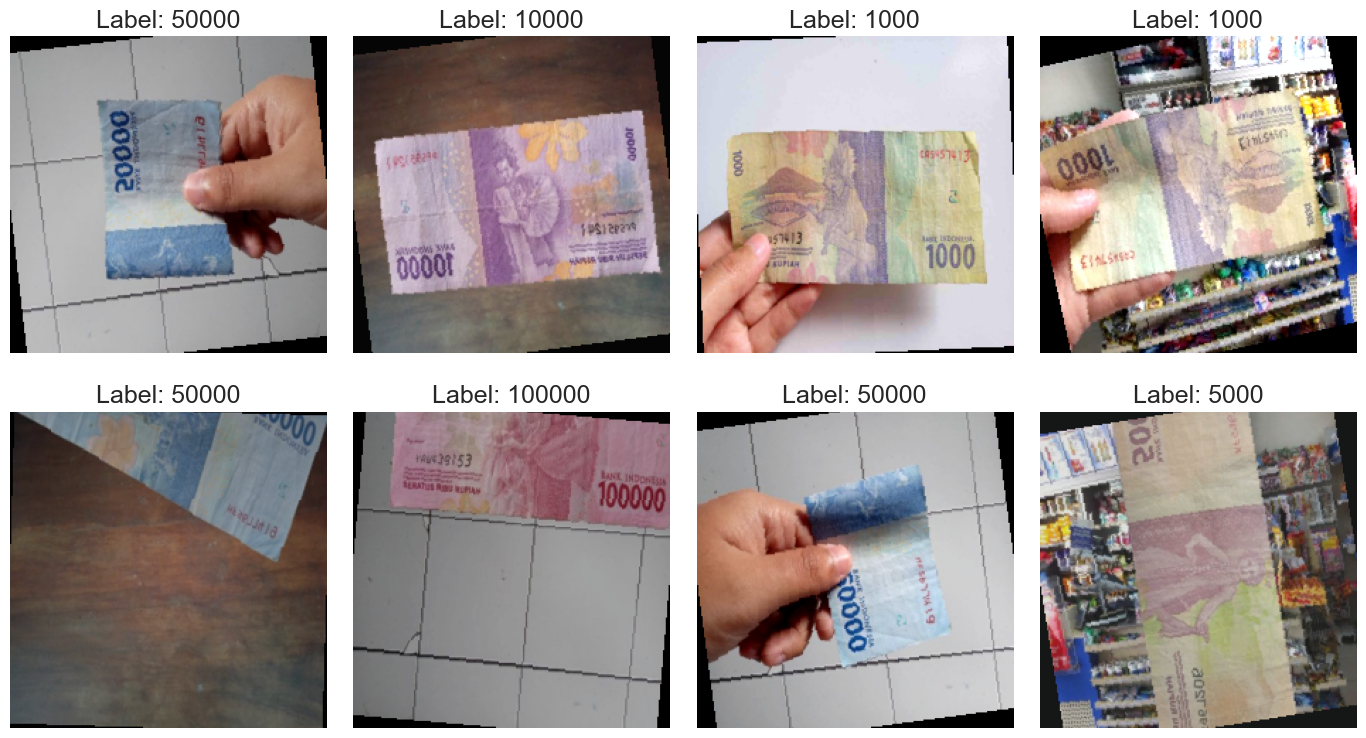

In [11]:
# BLOK 11 - VISUALISASI CONTOH DATA

def imshow_tensor(img_tensor, mean, std):
    # Membalik normalisasi agar gambar dapat ditampilkan dengan tampilan yang lebih natural.
    img = img_tensor.numpy().transpose(1, 2, 0)
    mean = np.array(mean)
    std = np.array(std)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Mengambil satu batch training untuk divisualisasikan.
images, labels = next(iter(train_loader))

plt.figure(figsize=(14, 8))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(imshow_tensor(images[i].cpu(), [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]))
    plt.title(f'Label: {CLASS_NAMES[labels[i].item()]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 12. Ketepatan pemilihan metode: ResNet18
Pada bagian ini akan dijelaskan apakah metode yang dipilih benar-benar sesuai dengan masalah.Karena proyek ini berbasis citra dan tujuannya klasifikasi multi-kelas, maka penggunaan ResNet18 sudah sangat sesuai.

### Alasan pemilihan ResNet18
- ResNet18 merupakan arsitektur CNN yang memang dirancang untuk klasifikasi citra.
- Transfer learning dari ImageNet biasanya lebih efektif daripada melatih CNN sederhana dari nol pada dataset terbatas.
- Residual connection membuat pelatihan jaringan lebih stabil dibanding CNN dasar tanpa residual path.
- Ukuran model masih cukup ringan untuk proyek kuliah, sehingga implementasinya realistis dari sisi waktu komputasi.

In [12]:
# BLOK 12 - DEFINISI MODEL RESNET18

# Mengambil bobot pretrained default dari torchvision agar model memanfaatkan transfer learning.
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Mengambil jumlah fitur masukan pada fully connected layer terakhir.
in_features = model.fc.in_features

# Mengganti layer klasifikasi akhir agar output sesuai jumlah kelas dataset.
model.fc = nn.Linear(in_features, NUM_CLASSES)

# Memindahkan model ke device (GPU/CPU).
model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## 13. Loss function, optimizer, dan scheduler

Pemilihan `CrossEntropyLoss`, `Adam`, dan `ReduceLROnPlateau` relevan dengan fine-tuning ResNet18 pada klasifikasi multi-kelas.

In [13]:
# BLOK 13 - LOSS FUNCTION, OPTIMIZER, DAN SCHEDULER

# CrossEntropyLoss digunakan karena output model berupa logits untuk klasifikasi multi-kelas.
criterion = nn.CrossEntropyLoss()

# Optimizer Adam dipakai karena stabil dan sederhana untuk fine-tuning.
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Scheduler menurunkan learning rate ketika validation loss tidak lagi membaik.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

## 14. Fungsi bantu untuk training dan evaluasi

Logika training dan evaluasi dipisahkan dalam fungsi yang jelas. Hal ini bertujuan agar Notebook lebih rapi dan mudah dipahami.

In [14]:
# BLOK 14 - FUNGSI TRAINING, EVALUASI, DAN UTILITAS

def count_parameters(model):
    # Menghitung total parameter model yang dapat dilatih.
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    # Mode training diaktifkan agar layer seperti BatchNorm bekerja sesuai pelatihan.
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images = images.to(device)
        labels = labels.to(device)

        # Membersihkan gradien lama.
        optimizer.zero_grad()

        # Forward pass.
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass dan update parameter.
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device, desc='Evaluation'):
    # Mode evaluasi diaktifkan agar inferensi konsisten dan hemat memori.
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc=desc, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, all_labels, all_preds


print('Jumlah parameter trainable:', f'{count_parameters(model):,}')

Jumlah parameter trainable: 11,180,103


## 15. Training model dan kontrol eksperimen

Training pada notebook ini dilengkapi pencatatan metrik per epoch, scheduler, early stopping, dan penyimpanan checkpoint terbaik.

In [17]:
# BLOK 15 - TRAINING MODEL RESNET18

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0
best_model_path = os.path.join(OUTPUT_DIR, 'best_resnet18_banknote.pth')

training_start_time = time.time()

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 60)

    epoch_start_time = time.time()

    # Training satu epoch.
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluasi pada validation set.
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device, desc='Validation')

    # Scheduler diperbarui berdasarkan validation loss.
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    epoch_time = time.time() - epoch_start_time

    print(f'Train Loss : {train_loss:.4f}')
    print(f'Train Acc  : {train_acc:.4f}')
    print(f'Val Loss   : {val_loss:.4f}')
    print(f'Val Acc    : {val_acc:.4f}')
    print(f'Waktu      : {epoch_time:.2f} detik')
    print(f'LR aktif   : {optimizer.param_groups[0]["lr"]:.8f}')

    # Menyimpan checkpoint terbaik berdasarkan validation loss.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0

        torch.save({
            'epoch': best_epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'class_names': CLASS_NAMES,
            'num_classes': NUM_CLASSES,
            'img_size': IMG_SIZE,
            'history': history,
        }, best_model_path)
        print('Model terbaik diperbarui dan disimpan.')
    else:
        patience_counter += 1
        print(f'Tidak ada perbaikan. Patience: {patience_counter}/{PATIENCE}')

    # Early stopping menghentikan training jika model tidak membaik terlalu lama.
    if patience_counter >= PATIENCE:
        print('Early stopping aktif. Training dihentikan lebih awal.')
        break

training_time = time.time() - training_start_time
print(f'Total waktu training: {training_time:.2f} detik')
print(f'Epoch terbaik       : {best_epoch}')
print(f'Best val loss       : {best_val_loss:.4f}')

Epoch 1/20
------------------------------------------------------------


Train Loss : 0.7639
Train Acc  : 0.7720
Val Loss   : 0.0338
Val Acc    : 0.9972
Waktu      : 58.65 detik
LR aktif   : 0.00010000
Model terbaik diperbarui dan disimpan.
Epoch 2/20
------------------------------------------------------------


Train Loss : 0.0452
Train Acc  : 0.9946
Val Loss   : 0.0109
Val Acc    : 1.0000
Waktu      : 28.41 detik
LR aktif   : 0.00010000
Model terbaik diperbarui dan disimpan.
Epoch 3/20
------------------------------------------------------------


Train Loss : 0.0291
Train Acc  : 0.9952
Val Loss   : 0.0091
Val Acc    : 1.0000
Waktu      : 29.30 detik
LR aktif   : 0.00010000
Model terbaik diperbarui dan disimpan.
Epoch 4/20
------------------------------------------------------------


Train Loss : 0.0151
Train Acc  : 0.9994
Val Loss   : 0.0037
Val Acc    : 1.0000
Waktu      : 25.01 detik
LR aktif   : 0.00010000
Model terbaik diperbarui dan disimpan.
Epoch 5/20
------------------------------------------------------------


...

Train Loss : 0.0072
Train Acc  : 0.9982
Val Loss   : 0.0011
Val Acc    : 1.0000
Waktu      : 16.50 detik
LR aktif   : 0.00005000
Tidak ada perbaikan. Patience: 1/5
Epoch 17/20
------------------------------------------------------------


Train Loss : 0.0043
Train Acc  : 0.9994
Val Loss   : 0.0010
Val Acc    : 1.0000
Waktu      : 16.34 detik
LR aktif   : 0.00005000
Tidak ada perbaikan. Patience: 2/5
Epoch 18/20
------------------------------------------------------------


Train Loss : 0.0018
Train Acc  : 1.0000
Val Loss   : 0.0006
Val Acc    : 1.0000
Waktu      : 16.46 detik
LR aktif   : 0.00005000
Model terbaik diperbarui dan disimpan.
Epoch 19/20
------------------------------------------------------------


Train Loss : 0.0026
Train Acc  : 1.0000
Val Loss   : 0.0005
Val Acc    : 1.0000
Waktu      : 16.98 detik
LR aktif   : 0.00005000
Model terbaik diperbarui dan disimpan.
Epoch 20/20
------------------------------------------------------------


Train Loss : 0.0039
Train Acc  : 0.9988
Val Loss   : 0.0008
Val Acc    : 1.0000
Waktu      : 17.43 detik
LR aktif   : 0.00005000
Tidak ada perbaikan. Patience: 1/5
Total waktu training: 407.08 detik
Epoch terbaik       : 19
Best val loss       : 0.0005


## 16. Memuat checkpoint terbaik

Pada evaluasi akhir memakai checkpoint terbaik, bukan otomatis bobot epoch terakhir. Hal ini bertujuan membuat prosedur eksperimen lebih sesuai secara metodologis.

In [18]:
# BLOK 16 - MEMUAT MODEL TERBAIK

checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

print('Model terbaik berhasil dimuat dari :', best_model_path)
print('Best epoch                        :', checkpoint['epoch'])
print('Best val loss                     :', checkpoint['best_val_loss'])

Model terbaik berhasil dimuat dari : ./hasil_resnet18_project\best_resnet18_banknote.pth
Best epoch                        : 19
Best val loss                     : 0.0004670445590961484


## 17. Evaluasi final pada test set

Agar evaluasi berkualitas Notebook menggunakan metrik accuracy, macro precision, macro recall, dan macro F1-score untuk evaluasi akhir.

In [19]:
# BLOK 17 - EVALUASI FINAL PADA TEST SET

test_loss, test_acc, test_labels, test_preds = evaluate(model, test_loader, criterion, device, desc='Test')

test_precision = precision_score(test_labels, test_preds, average='macro', zero_division=0)
test_recall = recall_score(test_labels, test_preds, average='macro', zero_division=0)
test_f1 = f1_score(test_labels, test_preds, average='macro', zero_division=0)

print('=' * 60)
print('HASIL EVALUASI FINAL RESNET18')
print('=' * 60)
print(f'Test Loss       : {test_loss:.4f}')
print(f'Test Accuracy   : {test_acc:.4f}')
print(f'Macro Precision : {test_precision:.4f}')
print(f'Macro Recall    : {test_recall:.4f}')
print(f'Macro F1-Score  : {test_f1:.4f}')
print(f'Jumlah Parameter: {count_parameters(model):,}')
print(f'Waktu Training  : {training_time:.2f} detik')
print('=' * 60)

HASIL EVALUASI FINAL RESNET18
Test Loss       : 0.0007
Test Accuracy   : 1.0000
Macro Precision : 1.0000
Macro Recall    : 1.0000
Macro F1-Score  : 1.0000
Jumlah Parameter: 11,180,103
Waktu Training  : 407.08 detik


## 18. Visualisasi training curve

Kurva training dan validation membantu melihat pola pembelajaran model, indikasi konvergensi, dan kemungkinan overfitting. Visualisasi yang membantu pemahaman juga menjadi bagian dari kualitas notebook.

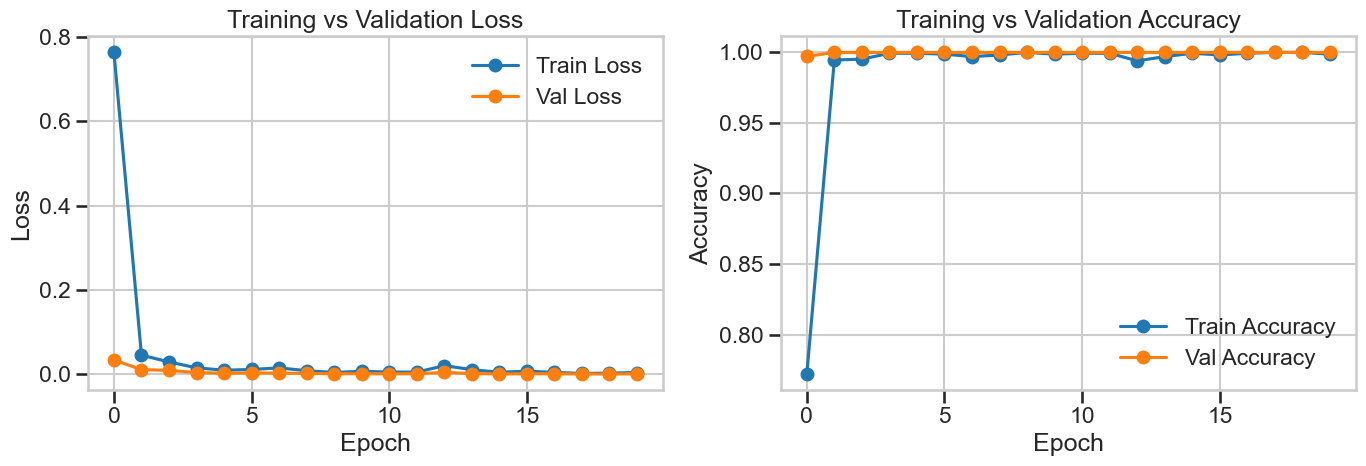

In [20]:
# BLOK 18 - VISUALISASI TRAINING CURVE

plt.figure(figsize=(14, 5))

# Kurva loss train dan validation.
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Kurva akurasi train dan validation.
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(history['val_acc'], label='Val Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 19. Confusion matrix dan classification report

Berikut confusion matrix dan classification report per kelas, bukan hanya metrik agregat. Diharapkan ini menjadi metrik yang tepat dan hasil dapat dianalisis dengan baik.

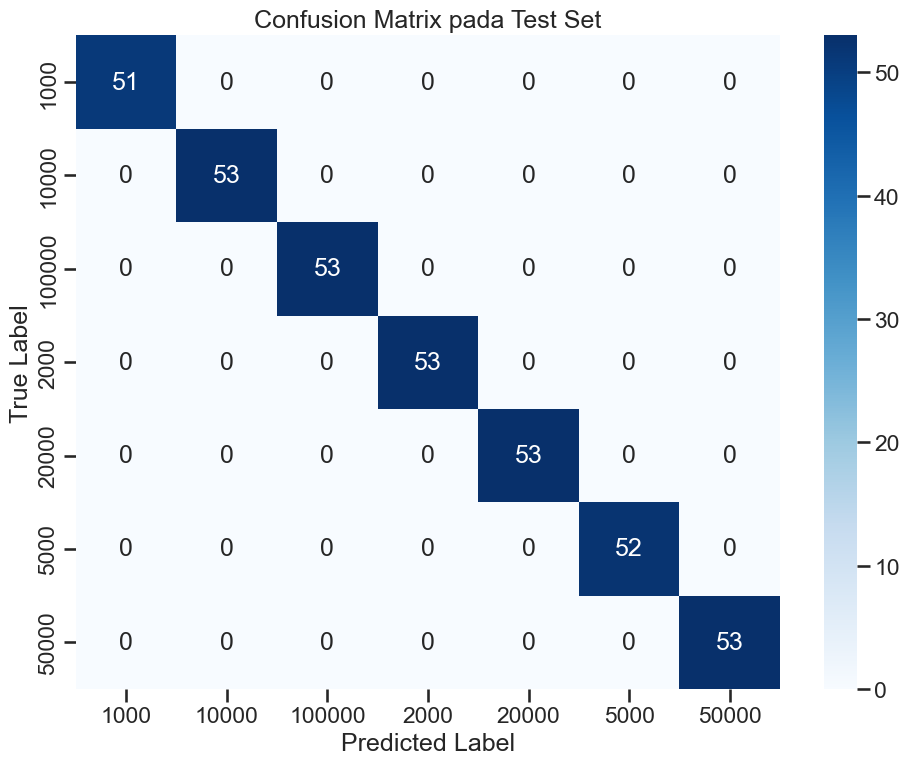

,precision,recall,f1-score,support
1000,1.0,1.0,1.0,51.0
10000,1.0,1.0,1.0,53.0
100000,1.0,1.0,1.0,53.0
2000,1.0,1.0,1.0,53.0
20000,1.0,1.0,1.0,53.0
5000,1.0,1.0,1.0,52.0
50000,1.0,1.0,1.0,53.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,368.0
weighted avg,1.0,1.0,1.0,368.0


In [21]:
# BLOK 19 - CONFUSION MATRIX DAN CLASSIFICATION REPORT

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix pada Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

report_dict = classification_report(test_labels, test_preds, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)
report_df.to_csv(os.path.join(OUTPUT_DIR, 'classification_report.csv'))

## 20. Analisis error / salah klasifikasi

Bagian ini akan melakukan pengecekan hasil secara logis, sehingga bukan sekadar menampilkan angka.

In [22]:
# BLOK 20 - ANALISIS SALAH KLASIFIKASI

model.eval()
misclassified_samples = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(labels)):
            if preds[i].item() != labels[i].item():
                misclassified_samples.append({
                    'true_label': CLASS_NAMES[labels[i].item()],
                    'pred_label': CLASS_NAMES[preds[i].item()]
                })

misclassified_df = pd.DataFrame(misclassified_samples)
if len(misclassified_df) > 0:
    display(misclassified_df.head(20))
    error_summary = misclassified_df.groupby(['true_label', 'pred_label']).size().reset_index(name='count')
    display(error_summary.sort_values('count', ascending=False))
    error_summary.to_csv(os.path.join(OUTPUT_DIR, 'error_analysis.csv'), index=False)
else:
    print('Tidak ada salah klasifikasi pada test set.')

Tidak ada salah klasifikasi pada test set.


## 21. Contoh prediksi model

Contoh prediksi membantu memperjelas bagaimana model bekerja pada sampel nyata dan memperkuat kualitas presentasi notebook.

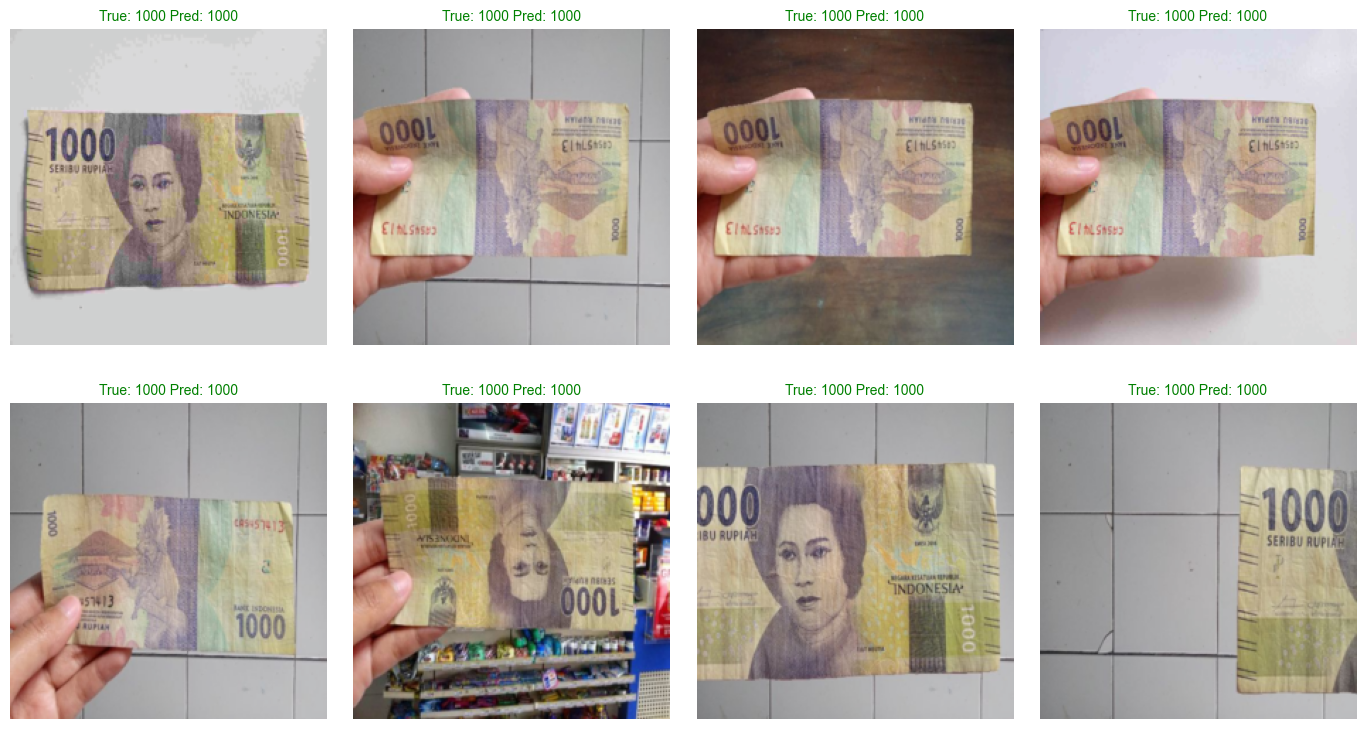

In [24]:
# BLOK 21 - CONTOH PREDIKSI PADA DATA TEST

images, labels = next(iter(test_loader))
images_device = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images_device)
    preds = torch.argmax(outputs, dim=1)

plt.figure(figsize=(14, 8))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(imshow_tensor(images[i].cpu(), [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]))
    true_label = CLASS_NAMES[labels[i].item()]
    pred_label = CLASS_NAMES[preds[i].item()]
    title_color = 'green' if true_label == pred_label else 'red'
    plt.title(f'True: {true_label} Pred: {pred_label}', color=title_color, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 22. Interpretasi hasil dan pembahasan

Pada bagian ini akan dijelaskan mengenai pembahasan hasil dan korelasi dengan tujuan project.

### Panduan pembahasan hasil
- Jika nilai accuracy, precision, recall, dan F1-score tinggi, maka model berhasil mempelajari pola visual antar nominal dengan baik.
- Jika confusion matrix dominan di diagonal utama, maka mayoritas prediksi benar.
- Jika masih ada kesalahan, kemungkinan penyebabnya bisa berupa kemiripan desain nominal, pencahayaan, sudut pengambilan gambar, blur, atau ketidakseimbangan jumlah data.
- Jika train accuracy jauh lebih tinggi daripada validation/test accuracy, maka ada indikasi overfitting.

### Kaitan dengan tujuan proyek
Bila model menunjukkan performa tinggi pada test set, maka tujuan proyek untuk membangun sistem klasifikasi nominal uang berbasis ResNet18 dapat dikatakan tercapai. Namun, hasil tetap harus dibaca secara kritis karena performa pada dataset terkontrol belum tentu identik dengan performa di kondisi dunia nyata.

### 23 – Menyimpan model final dan ringkasan metrik

Pada blok ini, kita melakukan dua hal penting setelah proses training dan evaluasi model selesai:

1. **Menyimpan model final beserta metadata penting**  
   Model yang sudah dilatih disimpan ke dalam berkas `resnet18_banknote_complete.pth` di folder `OUTPUT_DIR`.  
   Selain `state_dict` dari model, kita juga menyimpan berbagai informasi pendukung yang berguna ketika model akan dimuat kembali, antara lain:
   - `classes` dan `num_classes`: daftar nama kelas dan jumlah kelas target.
   - `img_size`: ukuran input gambar yang digunakan saat training.
   - `architecture`: nama arsitektur model (misalnya *ResNet18-FineTuned*).
   - `test_acc`, `macro_precision`, `macro_recall`, `macro_f1`: metrik performa pada data uji.
   - `random_seed`, `best_epoch`, `best_val_loss`: informasi eksperimen terbaik.
   
   Penyimpanan dilakukan dengan `torch.save(...)` sehingga model bisa dengan mudah di-reload untuk inference atau eksperimen lanjutan tanpa perlu training ulang.

2. **Menyimpan ringkasan metrik ke dalam file CSV**  
   Seluruh metrik evaluasi akhir dirangkum ke dalam sebuah `DataFrame` pandas (`metrics_df`) yang berisi:
   - `test_loss` dan `test_accuracy`
   - `macro_precision`, `macro_recall`, dan `macro_f1`
   - `best_epoch` dan `best_val_loss`
   - `training_time_sec`: durasi training
   - `num_parameters`: jumlah parameter model

   DataFrame ini kemudian diekspor ke berkas `final_metrics_summary.csv` di `OUTPUT_DIR`.  
   File CSV ini memudahkan integrasi metrik ke laporan, notebook lain, atau slide presentasi tanpa harus membuka ulang kode atau log training.

Di akhir blok, skrip juga mencetak lokasi file model (`.pth`) dan file ringkasan metrik (`.csv`) sehingga pengguna dapat dengan cepat mengetahui di mana artefak eksperimen disimpan.

In [ ]:
# BLOK 23 - MENYIMPAN MODEL FINAL DAN RINGKASAN METRIK

final_model_path = os.path.join(OUTPUT_DIR, 'resnet18_banknote_complete.pth')

# Menyimpan model final beserta metadata penting agar mudah digunakan kembali.
torch.save({
    'model_state_dict': model.state_dict(),
    'classes': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'architecture': 'ResNet18-FineTuned',
    'test_accuracy': test_acc,
    'macro_precision': test_precision,
    'macro_recall': test_recall,
    'macro_f1': test_f1,
    'random_seed': RANDOM_SEED,
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss,
}, final_model_path)

# Menyimpan ringkasan metrik akhir agar mudah dipakai dalam laporan atau slide presentasi.
metrics_df = pd.DataFrame([{
    'test_loss': test_loss,
    'test_accuracy': test_acc,
    'macro_precision': test_precision,
    'macro_recall': test_recall,
    'macro_f1': test_f1,
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss,
    'training_time_sec': training_time,
    'num_parameters': count_parameters(model),
}])
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'final_metrics_summary.csv'), index=False)

print('Model final tersimpan di:', final_model_path)
print('Ringkasan metrik tersimpan di:', os.path.join(OUTPUT_DIR, 'final_metrics_summary.csv'))

Model final tersimpan di: ./hasil_resnet18_project\resnet18_banknote_complete.pth
Ringkasan metrik tersimpan di: ./hasil_resnet18_project\final_metrics_summary.csv
